In [122]:
import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

randon_state = 42

print("libraries impoted successfully")

libraries impoted successfully


In [123]:
import sys

print(sys.executable)

/Users/rahulkumar/Desktop/fake-news-classifier/.venv/bin/python


In [124]:
#Loading dataset
fake_path = "../data/raw-data/Fake.csv"
true_path = "../data/raw-data/True.csv"


print("Fake file:", fake_path)
print("True file:", true_path)


Fake file: ../data/raw-data/Fake.csv
True file: ../data/raw-data/True.csv


In [125]:

if not os.path.exists(fake_path):
    fake_path = None
if not os.path.exists(true_path):
    true_path = None


fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)


print("Shape of Fake dataset : ",fake_df.shape)
print("Shape of True dataset : ",true_df.shape)


Shape of Fake dataset :  (23481, 4)
Shape of True dataset :  (21417, 4)


In [126]:
fake_df = fake_df.copy()
true_df = true_df.copy()

In [127]:

fake_df["label"] = 0
true_df["label"] = 1
df = pd.concat([fake_df,true_df,],ignore_index = True)

# Combine the two Dataframes
print("Combined dataset shape: ", df.shape)

Combined dataset shape:  (44898, 5)


In [128]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [130]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [131]:
print("Dataset Shape:\n",df.shape)

print("\nColumns:\n",df.columns)

print("\nData Types:\n",df.dtypes)

Dataset Shape:
 (44898, 5)

Columns:
 Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

Data Types:
 title        str
text         str
subject      str
date         str
label      int64
dtype: object


In [132]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


#Data Cleaning & Preprocessing

In [133]:
#remove duplicates

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal :", after)
print("Duplicates removed            :", before - after)


Rows before duplicate removal: 44898
Rows after duplicate removal : 44689
Duplicates removed            : 209


In [134]:
text_columns = ["title", "text"]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("")

df["content"] = (df["title"].astype(str) + " " + df["text"].astype(str))
df["content"] = df["content"].str.strip() #it removes any leading or trailing whitespac
df = df[df["content"].str.len() > 20].copy()
df = df[['content','label']]
print("dataset after text cleaning:", df.shape)
df.columns

dataset after text cleaning: (44689, 2)


Index(['content', 'label'], dtype='str')

In [135]:
# check class distribution
label_counts = df["label"].value_counts().sort_index()

print("class distribution:")
print(label_counts)

print("\npercentages:")
print(df["label"].value_counts(normalize=True).sort_index().mul(100).round(2))

class distribution:
label
0    23478
1    21211
Name: count, dtype: int64

percentages:
label
0    52.54
1    47.46
Name: proportion, dtype: float64


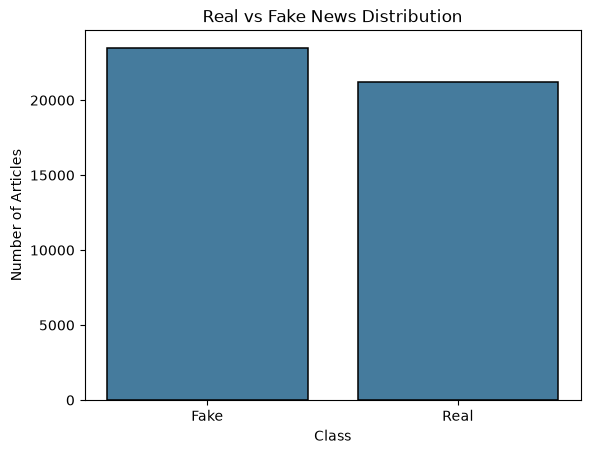

In [136]:
plt.hist(
    data=df, 
    x="label", 
    bins=2, 
    color="#457B9D", # Only one color allowed here
    edgecolor="black", 
    linewidth=1.1,
    rwidth=0.8 # Makes the bars slightly thinner
)

plt.title("Real vs Fake News Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.xticks([0.25, 0.75], ["Fake", "Real"]) # Centers the labels under the bars
plt.show()



<H3>NLP Preprocessing</H3>
<h4>The raw news articles contain punctuation, URLs, numbers and other elements that may introduce unnecessary noise.</h4>
<h5>The preprocessing pipeline:</h5>
<h6>
Convert text to lowercase<br>
Remove URLs<br>
Remove HTML tags<br>
Remove punctuation<br>
Remove numbers<br>
Normalize whitespace<br></h6>

In [137]:
import re
import pandas as pd

def clean_text(text):
    # Fix 1: Guard against NaN, None, or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # 1. Remove City Datelines like 'WASHINGTON (Reuters) - ' or '(Reuters) - '
    # (Matches capital city names right before (Reuters) before lowercasing)
    text = re.sub(r"\b[A-Z\s\/]{2,25}\s*\(\s*[Rr]euters\s*\)\s*[-–—:]?\s*", " ", text)
    text = re.sub(r"\(\s*[Rr]euters\s*\)\s*[-–—:]?\s*", " ", text)
    
    text = text.lower()
    
    # 2. Remove URLs (including pic.twitter.com and twitter links)
    text = re.sub(r"https?://\S+|www\.\S+|pic\.twitter\.com/\S+|twitter\.com/\S+", " ", text)
    
    # 3. Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # 4. Remove wire sign-offs & agency mentions (anywhere in body)
    text = re.sub(r"\b(?:reporting\s+by|editing\s+by|writing\s+by)\b.*$", " ", text)
    text = re.sub(r"\breuters\b", " ", text)
    text = re.sub(r"\bassociated\s+press\b|\bap\s+news\b|\bafp\b", " ", text)
    
    # 5. Remove fake news footers, image credits & media tags
    text = re.sub(r"\b(?:featured\s+)?image\s+via\b[^\.\n]*", " ", text)
    text = re.sub(r"\bphoto\s+by\b[^\.\n]*", " ", text)
    text = re.sub(r"\bgetty\s+images\b|\bvia\s+getty\b", " ", text)
    text = re.sub(r"\bfollow\s+us\s+on\s+(?:twitter|facebook)\b[^\.\n]*", " ", text)
    text = re.sub(r"\bwatch\s+video\b|\bvideo\b|\bclick\s+here\b[^\.\n]*", " ", text)
    
    # 6. Remove days of the week & months (removes AP/Reuters wire calendar bias)
    text = re.sub(
        r"\b(monday|tuesday|wednesday|thursday|friday|saturday|sunday)\b|"
        r"\b(january|february|march|april|may|june|july|august|september|october|november|december)\b|"
        r"\b(jan|feb|mar|apr|jun|jul|aug|sep|sept|oct|nov|dec)\b", 
        " ", 
        text
    )
    
    # 7. Keep only alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # 8. Normalize extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Now this runs cleanly with zero TypeErrors:
df["clean_text"] = df["content"].apply(clean_text)

# Remove any rows that became empty during cleaning or are under 20 words
df["word_count"] = df["clean_text"].str.split().str.len()
df = df[df["word_count"] >= 20].copy()

# Deduplicate after cleaning
before = len(df)
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}")
print(f"Clean rows remaining: {len(df):,}")

Duplicates removed: 5655
Clean rows remaining: 38,322


In [138]:
for i in range(3):
    print("-" * 90)

    print("ORIGINAL:")
    print(df["content"].iloc[i][:500])

    print("\nCLEANED:")
    print(df["clean_text"].iloc[i][:500])

    print()


------------------------------------------------------------------------------------------
ORIGINAL:
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a

CLEANED:
donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want

In [139]:

# text length analysis

df["word_count"] = df["clean_text"].str.split().str.len()

print(df["word_count"].describe())

count    38322.000000
mean       413.829289
std        315.872028
min         20.000000
25%        228.000000
50%        379.000000
75%        522.000000
max       8224.000000
Name: word_count, dtype: float64


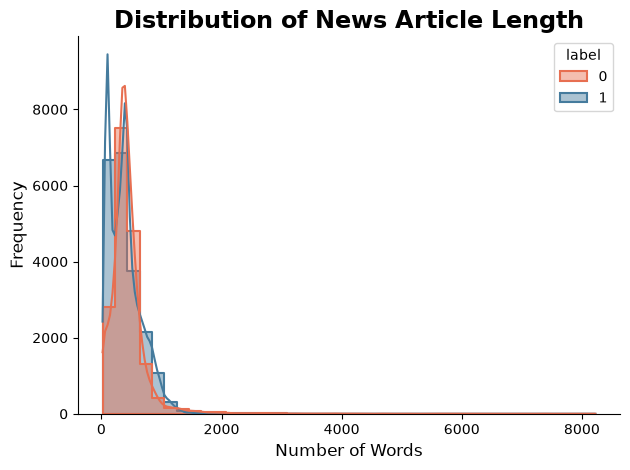

In [140]:

sns.histplot(data = df,x = "word_count",hue = "label",bins=40,kde = True,palette=["#E76F51", "#457B9D"],
        alpha = 0.45,element = "step",linewidth =1.5)
plt.title("Distribution of News Article Length", fontsize=17, fontweight="bold")
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

sns.despine()
plt.tight_layout()

plt.show()

/var/folders/p4/60m358jj4yxf2zj5dk4cg0m00000gn/T/ipykernel_34165/1598819643.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


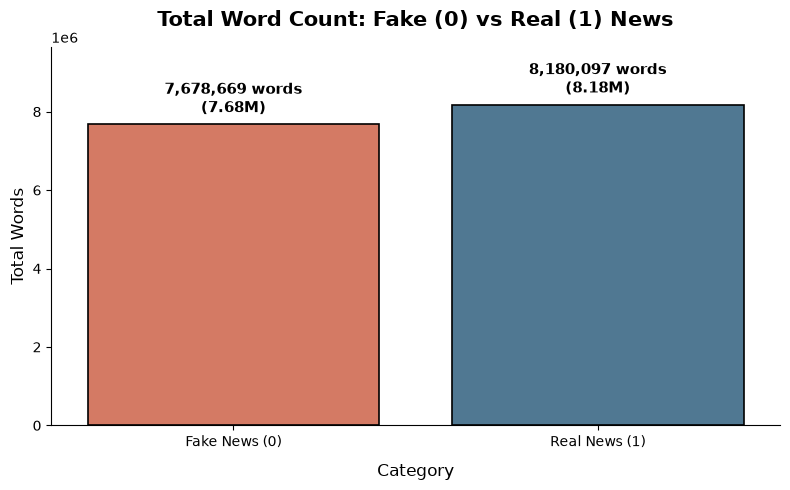

In [141]:
total_words = df.groupby("label")["word_count"].sum().reset_index()
total_words["label_name"] = total_words["label"].map({0: "Fake News (0)", 1: "Real News (1)"})
# 2. Plotting
plt.figure(figsize=(8, 5))
colors = ["#E76F51", "#457B9D"]  # Orange for Fake, Blue for Real
ax = sns.barplot(
    data=total_words,
    x="label_name",
    y="word_count",
    palette=colors,
    edgecolor="black",
    linewidth=1.2,
)
# 3. Add values on top of each bar (formatted in Millions for readability)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(
        f"{int(val):,} words\n({val / 1e6:.2f}M)",
        (p.get_x() + p.get_width() / 2.0, val),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.title("Total Word Count: Fake (0) vs Real (1) News", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Category", fontsize=12, labelpad=10)
plt.ylabel("Total Words", fontsize=12)
plt.ylim(0, total_words["word_count"].max() * 1.18)  # Leave room for labels
sns.despine()
plt.tight_layout()
plt.show()

In [142]:
df.columns

Index(['content', 'label', 'clean_text', 'word_count'], dtype='str')

In [144]:
pcs_df = df[["clean_text", "label"]].copy()
print(pcs_df.shape)
print(pcs_df.head())

(38322, 2)
                                          clean_text  label
0  donald trump sends out embarrassing new year s...      0
1  drunk bragging trump staffer started russian c...      0
2  sheriff david clarke becomes an internet joke ...      0
3  trump is so obsessed he even has obama s name ...      0
4  pope francis just called out donald trump duri...      0


In [145]:
pcs_df = pcs_df.sample(frac=1, random_state=42).reset_index(drop=True)

pcs_df.head(20)

,clean_text,label
0,lebanon army chief warns of israel threat amid...,1
1,in schools and hospitals turkey carves north s...,1
2,yikes academy award winning actor starring in ...,0
3,ted cruz slams jorge ramos on the rule of law ...,0
4,keith scott s brother tells charlotte reporter...,0
5,leaked audio ceo of cbs gleefully celebrates t...,0
6,boris and brexit sour british pm theresa s par...,1
7,school employee calls for killing lgbtq people...,0
8,sean hannity is a deranged maniac who pulled a...,0
9,iraq shi ite paramilitary calls for ban on u s...,1


In [146]:
label_counts = pcs_df["label"].value_counts().sort_index()

print("class distribution:")
print(label_counts)

print("\npercentages:")
print(pcs_df["label"].value_counts(normalize=True).sort_index().mul(100).round(2))

class distribution:
label
0    17397
1    20925
Name: count, dtype: int64

percentages:
label
0    45.4
1    54.6
Name: proportion, dtype: float64


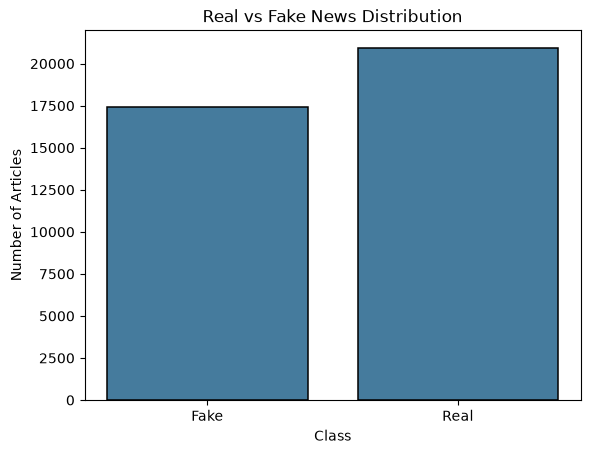

In [147]:
plt.hist(
    data=df, 
    x="label", 
    bins=2, 
    color="#457B9D", # Only one color allowed here
    edgecolor="black", 
    linewidth=1.1,
    rwidth=0.8 # Makes the bars slightly thinner
)

plt.title("Real vs Fake News Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.xticks([0.25, 0.75], ["Fake", "Real"]) # Centers the labels under the bars
plt.show()


In [148]:
output_folder = "../data/processed_data"
os.makedirs(output_folder,exist_ok = True)
output_file = os.path.join(output_folder, "clean_news_data.csv")
pcs_df.to_csv(output_file, index=False)

print(f"✅ Successfully saved to {output_file}")

✅ Successfully saved to ../data/processed_data/clean_news_data.csv
